
# 📘 Module 20: AdaBoost (Adaptive Boosting) – Practice Notebook

This is a **full practice notebook with detailed guidance and TODO blocks**.


## 0. Notebook Setup

We start by importing all required libraries.  


In [2]:
# TODO: Import all required libraries (Done for you)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


## 1. Understanding the Dataset

You can begin with a **synthetic binary classification dataset**. or with any exisiting dataset.

Focus questions:
- Are the classes easily separable?
- Will a weak learner struggle?


In [3]:
# TODO: Generate a binary classification dataset
# Hint:
# - n_samples around 500
# - n_features = 2
# - class_sep > 1

X, y = make_classification(
    n_samples = 500,
    n_features=2,
    n_redundant = 0,
    n_informative = 2,
    n_clusters_per_class=1,
    class_sep=1.5,
    random_state=42
)

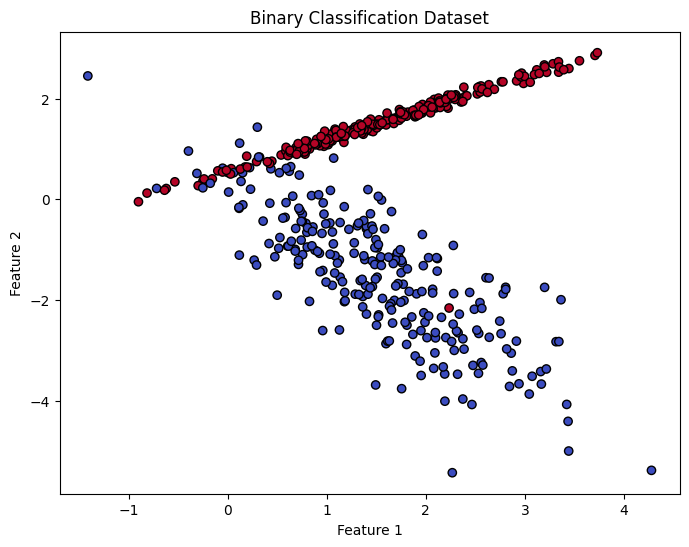

In [4]:
# TODO: Visualize the dataset using a scatter plot
# Color points by class label

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Binary Classification Dataset")
plt.show()


## 2. Train–Test Split

Before any model training, we split the data.

Why?
- To evaluate generalization
- To avoid lying to ourselves

Standard split:
- 70% training
- 30% testing


In [5]:
# TODO: Split the dataset into training and testing sets
# Use test_size=0.3 and random_state=42

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state = 42
)
print("Training set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape)

Training set: (350, 2) (350,)
Test set: (150, 2) (150,)



## 3. Baseline Weak Learner (Decision Stump)

Before AdaBoost, we test **one weak learner alone**.

We intentionally restrict the model:
- max_depth = 1
- This is called a **decision stump**

Expectation:
- Accuracy will not be impressive
- That is the point


In [6]:
# TODO: Create a DecisionTreeClassifier with max_depth=1
# SVM, Logistic Regression
# This is our weak learner
weak_learner = DecisionTreeClassifier(
    max_depth = 1,
    random_state = 42
)

In [7]:
# TODO: Train the weak learner
# TODO: Predict on test data
# TODO: Calculate and print accuracy
weak_learner.fit(X_train, y_train)
y_pred = weak_learner.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Weak Learner Accuracy: {accuracy:.4f}")

Weak Learner Accuracy: 0.9400



## 4. AdaBoost Classifier – Core Practice

Now we combine **many weak learners** using AdaBoost.

Key idea:
- Each learner focuses more on previous mistakes
- Misclassified samples get more attention
- Correctly classified samples slowly matter less


In [8]:
# TODO: Initialize AdaBoostClassifier
# Use:
# - base_estimator = decision stump
# - n_estimators = 50
# - learning_rate = 1.0
adaboost = AdaBoostClassifier(
    estimator = weak_learner,
    n_estimators = 50,
    learning_rate = 1.0,
    random_state = 42
)

In [9]:
# TODO: Train AdaBoost on training data
# TODO: Predict on test data
# TODO: Evaluate accuracy
# TODO: Print classification report
adaboost.fit(X_train, y_train)
y_pred_ada = adaboost.predict(X_test)
accuracy_ada = accuracy_score(y_test, y_pred_ada)
print(f"AdaBoost Accuracy: {accuracy_ada:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_ada))

AdaBoost Accuracy: 0.9333

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.96      0.94        75
           1       0.96      0.91      0.93        75

    accuracy                           0.93       150
   macro avg       0.93      0.93      0.93       150
weighted avg       0.93      0.93      0.93       150




## 5. Weak Learner vs AdaBoost Comparison

Now we compare:
- One weak learner
- Many weak learners working together

Expectation:
- AdaBoost should outperform a single stump
- If not, something is wrong


In [10]:
# TODO: Create a comparison table
# Columns:
# - Model
# - Accuracy
comparison = pd.DataFrame({
    "Model": ["Decision stump", "Adaboost"],
    "Accuracy":[accuracy, accuracy_ada]
})
comparison["Accuracy"] = comparison["Accuracy"].round(4)
print(comparison)

            Model  Accuracy
0  Decision stump    0.9400
1        Adaboost    0.9333



## 6. Effect of Number of Estimators

AdaBoost performance depends heavily on:
- Number of estimators

More is not always better.

Your job:
- Experiment
- Observe
- Plot


In [14]:
# TODO: Try different n_estimators values
# Example: [5, 10, 20, 50, 100]

# Store accuracy for each value
n_estimators_list = [5, 10, 20, 50, 100]
accuracies = []

for n in n_estimators_list:
    model = AdaBoostClassifier(
        estimator=weak_learner,
        n_estimators=n,
        learning_rate=1.0,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    print(f"n_estimators={n}: Accuracy={acc:.4f}")

n_estimators=5: Accuracy=0.8867
n_estimators=10: Accuracy=0.8867
n_estimators=20: Accuracy=0.8867
n_estimators=50: Accuracy=0.9333
n_estimators=100: Accuracy=0.9333


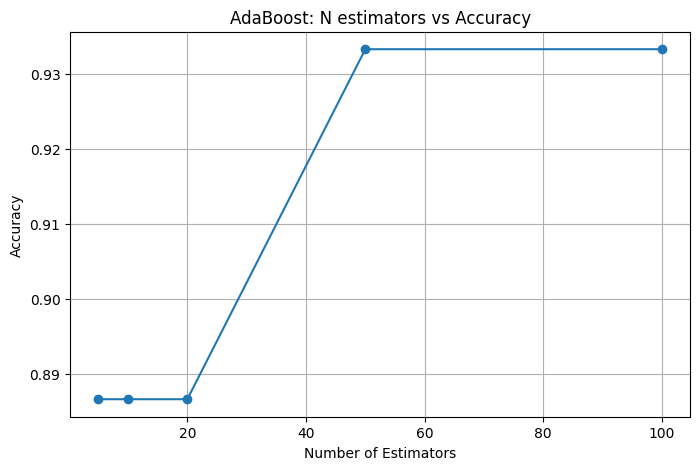

In [16]:
# TODO: Plot n_estimators vs accuracy
# Label axes clearly
plt.figure(figsize=(8, 5))
plt.plot(n_estimators_list, accuracies, marker='o')
plt.xlabel("Number of Estimators")
plt.ylabel("Accuracy")
plt.title("AdaBoost: N estimators vs Accuracy")
plt.grid(True)
plt.show()


## 7. Effect of Learning Rate

Learning rate controls **how aggressively** AdaBoost updates sample weights.

Intuition:
- High learning rate → fast but risky
- Low learning rate → slow but stable

You will verify this experimentally.


In [17]:
# TODO: Experiment with different learning_rate values
# Example: [0.01, 0.1, 0.5, 1.0]
learning_rates = [0.01, 0.1, 0.5, 1.0]
accuracies_lr = []

for lr in learning_rates:
  model = AdaBoostClassifier(
      estimator = weak_learner,
      n_estimators = 50,
      learning_rate = lr,
      random_state = 42
  )
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)

  acc = accuracy_score(y_test, y_pred)
  accuracies_lr.append(acc)
  print(f"learning_rate={lr}: Accuracy{acc:.4f}")

learning_rate=0.01: Accuracy0.9400
learning_rate=0.1: Accuracy0.9400
learning_rate=0.5: Accuracy0.9067
learning_rate=1.0: Accuracy0.9333


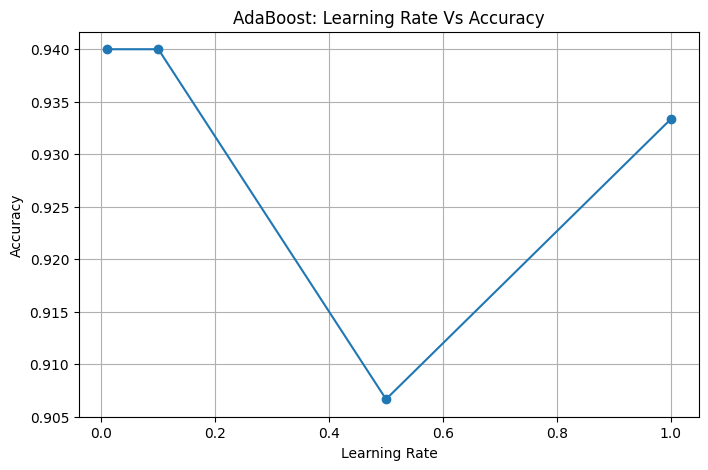

In [18]:
# TODO: Plot learning_rate vs accuracy
plt.figure(figsize=(8,5))
plt.plot(learning_rates, accuracies_lr, marker='o')
plt.xlabel("Learning Rate")
plt.ylabel("Accuracy")
plt.title("AdaBoost: Learning Rate Vs Accuracy")
plt.grid(True)
plt.show()


## 8. Feature Importance in AdaBoost

AdaBoost can tell us:
- Which features were more influential

This depends on:
- How often a feature is used in splits
- How strong the corresponding learners were


Feature Importances:
Feature 1: 0.3110
Feature 2: 0.6890


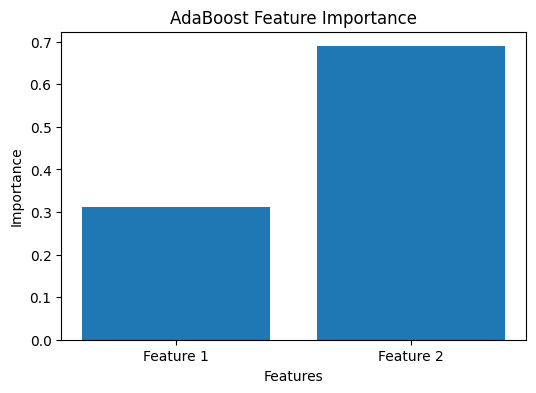

In [21]:
# TODO: Extract feature importance from AdaBoost
# TODO: Plot feature importance

feature_importance = adaboost.feature_importances_
print("Feature Importances:")
for i, importance in enumerate(feature_importance):
  print(f"Feature {i+1}: {importance:.4f}")

feature_names = [f"Feature {i+1}" for i in range(len(feature_importance))]
plt.figure(figsize=(6,4))
plt.bar(feature_names, feature_importance)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("AdaBoost Feature Importance")
plt.show()


## 9. Reflection (Mandatory)

Answer in your own words.

1. Why is AdaBoost called *adaptive*?

Ans:- AdaBoost is called adaptive because it adjusts the weights of training samples after each iteration, giving more attention to difficult samples that were previously misclassified.

2. What happens to misclassified samples after each iteration?

Ans:- Misclassified samples receive higher weights, so the next weak learner focuses more on correctly classifying them.

3. Why do we prefer weak learners instead of strong ones?

Ans:- AdaBoost is designed to combine many simple weak learners. Multiple weak learners can work together to create a strong model while reducing complexity and improving generalization.

4. When should AdaBoost not be used?

Ans:- AdaBoost should be avoided when the dataset contains a lot of noise, outliers, or incorrect labels because it tends to focus heavily on misclassified samples, which can lead to poor performance and overfitting.


## 10. Bonus Challenge (Optional)

Replace the decision stump with **Logistic Regression** as the base estimator.

Questions:
- Does AdaBoost still work?
- Should you do this in practice?
- Why or why not?


In [ ]:
# TODO: Replace DecisionTreeClassifier with LogisticRegression or SVM
# Train AdaBoost again
# Compare performance